In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import json
import requests
from sklearn.preprocessing import (OrdinalEncoder, LabelEncoder, OneHotEncoder,
    KBinsDiscretizer, Binarizer, StandardScaler, MinMaxScaler,
    MaxAbsScaler, RobustScaler, Normalizer, FunctionTransformer, PowerTransformer)
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer, MissingIndicator


## 📚 Step 1: Project Planning & Problem Framing

### Short Notes

**What is Data Analysis?**
Data analysis means collecting raw data and finding useful patterns or insights from it.
We clean it, explore it and make it ready for decision making or predictions.
Example — An e-commerce company wants to know which customers are likely to buy again, so they analyze past purchase data.

**Steps in a Data Science Project:**
1. Understand the business problem — what do we want to predict?
2. Collect data from various sources (CSV, JSON, SQL, API)
3. Clean the data — handle missing values, outliers, wrong types
4. Feature Engineering — create new meaningful columns
5. Build the ML model
6. Evaluate and deploy

**How to Frame This as an ML Problem?**
This is a **Binary Classification** problem.
- Input (X) = customer features like age, income, city, purchase history
- Output (Y) = `purchased` (0 = did not buy, 1 = bought)
- Algorithm type = **Supervised Learning** because we have labeled data
- Metric = F1 Score or ROC-AUC (suitable for classification)

## 📥 Step 2: Data Import and Understanding

In [85]:
# importing csv dataset

df_csv = pd.read_csv("customers.csv")
print(df_csv.head())

   customer_id    name   age  gender       city    income
0          101  Sunita  56.0    Male    Lucknow  166494.0
1          102   Priya  46.0  Female  Hyderabad  193540.0
2          103    Diya  32.0  Female    Lucknow   52371.0
3          104   Mohan  60.0  Female      Delhi   77022.0
4          105   Rahul  25.0    Male     Indore   91229.0


In [86]:
# importing json dataset

df_json = pd.read_json("transactions.json")
print(df_json.head())

  transaction_id  customer_id product_id  amount payment_mode       date  \
0          T0001          910       P003    1299  Credit Card 2025-03-31   
1          T0002          977       P006    2599         Cash 2025-09-21   
2          T0003          189       P004     899  Credit Card 2025-03-13   
3          T0004          432       P002     631         Cash 2025-05-17   
4          T0005          410       P005    1999          UPI 2025-05-14   

   quantity  
0         3  
1         2  
2         2  
3         2  
4         3  


In [87]:
# importing sql datset

conn = sqlite3.connect(":memory:")
with open("products.sql", "r") as f:
    sql_script = f.read()
conn.executescript(sql_script)
df_sql = pd.read_sql_query("SELECT * FROM products", conn)
print(df_sql.head())

  product_id       product_name     category  price  stock
0       P001          Earphones  Electronics    499     50
1       P002  Bluetooth Speaker        Audio    699     40
2       P003        Smart Watch     Wearable   1299     25
3       P004           Keyboard     Computer    899     60
4       P005         Headphones        Audio   1999     30


In [88]:
# # API data
# url = "https://dummyjson.com/users"
# api = requests.get(url).json()
# api_users = pd.json_normalize(api['users'])


In [89]:
df = df_json.merge(df_sql, on="product_id", how="left")
df = df.merge(df_csv, on="customer_id", how="left")
df.replace(["None","none","NULL","null","NaN","nan","N/A","n/a"," ","-"], np.nan, inplace=True)

print(df.shape)
df.head()

(1000, 16)


,transaction_id,customer_id,product_id,amount,payment_mode,date,quantity,product_name,category,price,stock,name,age,gender,city,income
0,T0001,910,P003,1299,Credit Card,2025-03-31,3,Smart Watch,Wearable,1299,25,Dinesh,27.0,Male,Kolkata,42207.0
1,T0002,977,P006,2599,Cash,2025-09-21,2,Power Bank,Mobile Accessories,2599,20,Satish,45.0,Male,Mumbai,189316.0
2,T0003,189,P004,899,Credit Card,2025-03-13,2,Keyboard,Computer,899,60,Rohan,62.0,Male,Hyderabad,103588.0
3,T0004,432,P002,631,Cash,2025-05-17,2,Bluetooth Speaker,Audio,699,40,Deepa,52.0,Male,Chandigarh,43284.0
4,T0005,410,P005,1999,UPI,2025-05-14,3,Headphones,Audio,1999,30,Usha,50.0,Male,Indore,41621.0


In [90]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  1000 non-null   object        
 1   customer_id     1000 non-null   int64         
 2   product_id      1000 non-null   object        
 3   amount          1000 non-null   int64         
 4   payment_mode    1000 non-null   object        
 5   date            1000 non-null   datetime64[ns]
 6   quantity        1000 non-null   int64         
 7   product_name    1000 non-null   object        
 8   category        1000 non-null   object        
 9   price           1000 non-null   int64         
 10  stock           1000 non-null   int64         
 11  name            1000 non-null   object        
 12  age             949 non-null    float64       
 13  gender          1000 non-null   object        
 14  city            1000 non-null   object        
 15  incom

## 🔍 Step 3: Exploratory Data Analysis (EDA)

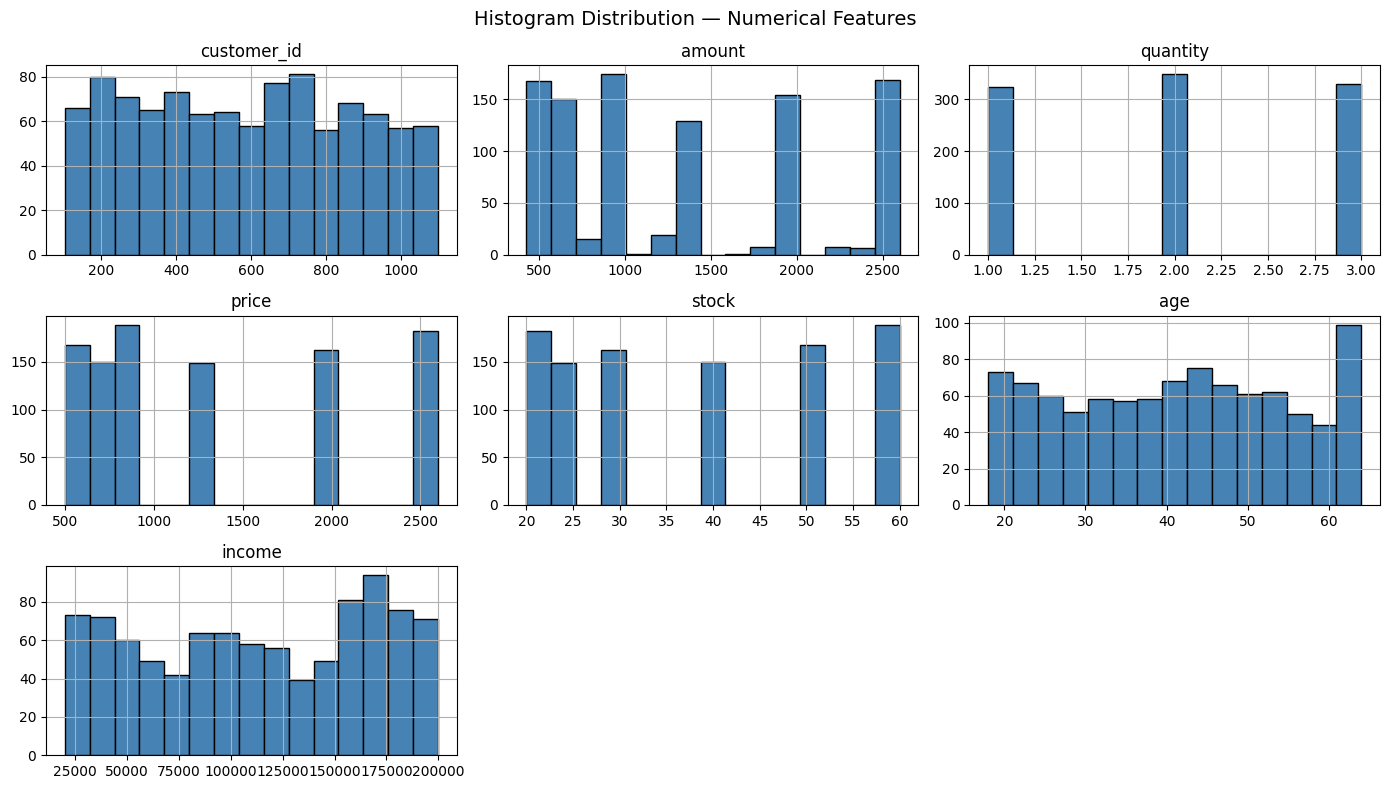

In [91]:
# univariate analysis
# Visualize the distribution of numerical columns using histograms

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

df[numerical_cols].hist(bins=15, figsize=(14, 8), color='steelblue', edgecolor='black')
plt.suptitle("Histogram Distribution — Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

In [92]:
# identify skewed variables
skewness = df[numerical_cols].skew().sort_values(ascending=False)
print("Skewness of numerical columns:")
print(skewness)

Skewness of numerical columns:
amount         0.549916
price          0.545739
stock          0.279609
customer_id    0.045916
quantity      -0.010912
age           -0.015844
income        -0.100010
dtype: float64


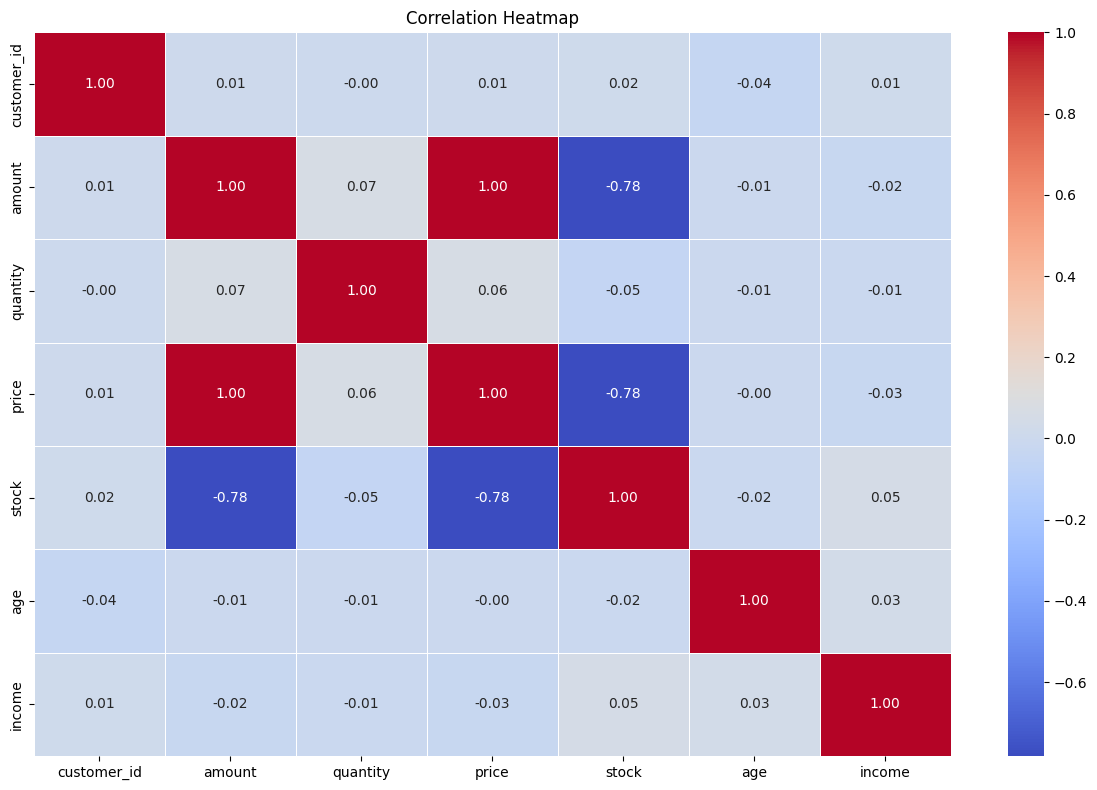

In [93]:
# Bivariate Analysis
# correlation heatmap

plt.figure(figsize=(12, 8))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


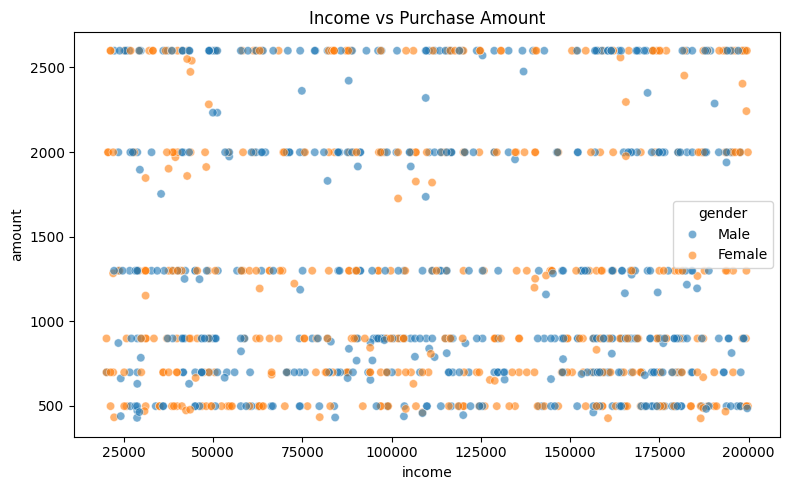

In [94]:
# income vs purchase amount
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="income", y="amount", hue="gender", alpha=0.6)
plt.title("Income vs Purchase Amount")
plt.tight_layout()
plt.show()

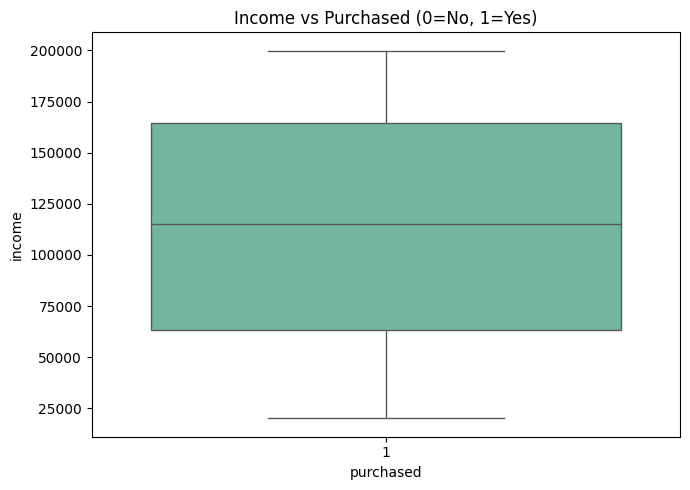

In [95]:
# compare means: income vs purchased
purchased_customers = set(df_json["customer_id"].unique())
df["purchased"] = df["customer_id"].apply(lambda x: 1 if x in purchased_customers else 0)

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="purchased", y="income", palette="Set2")
plt.title("Income vs Purchased (0=No, 1=Yes)")
plt.tight_layout()
plt.show()

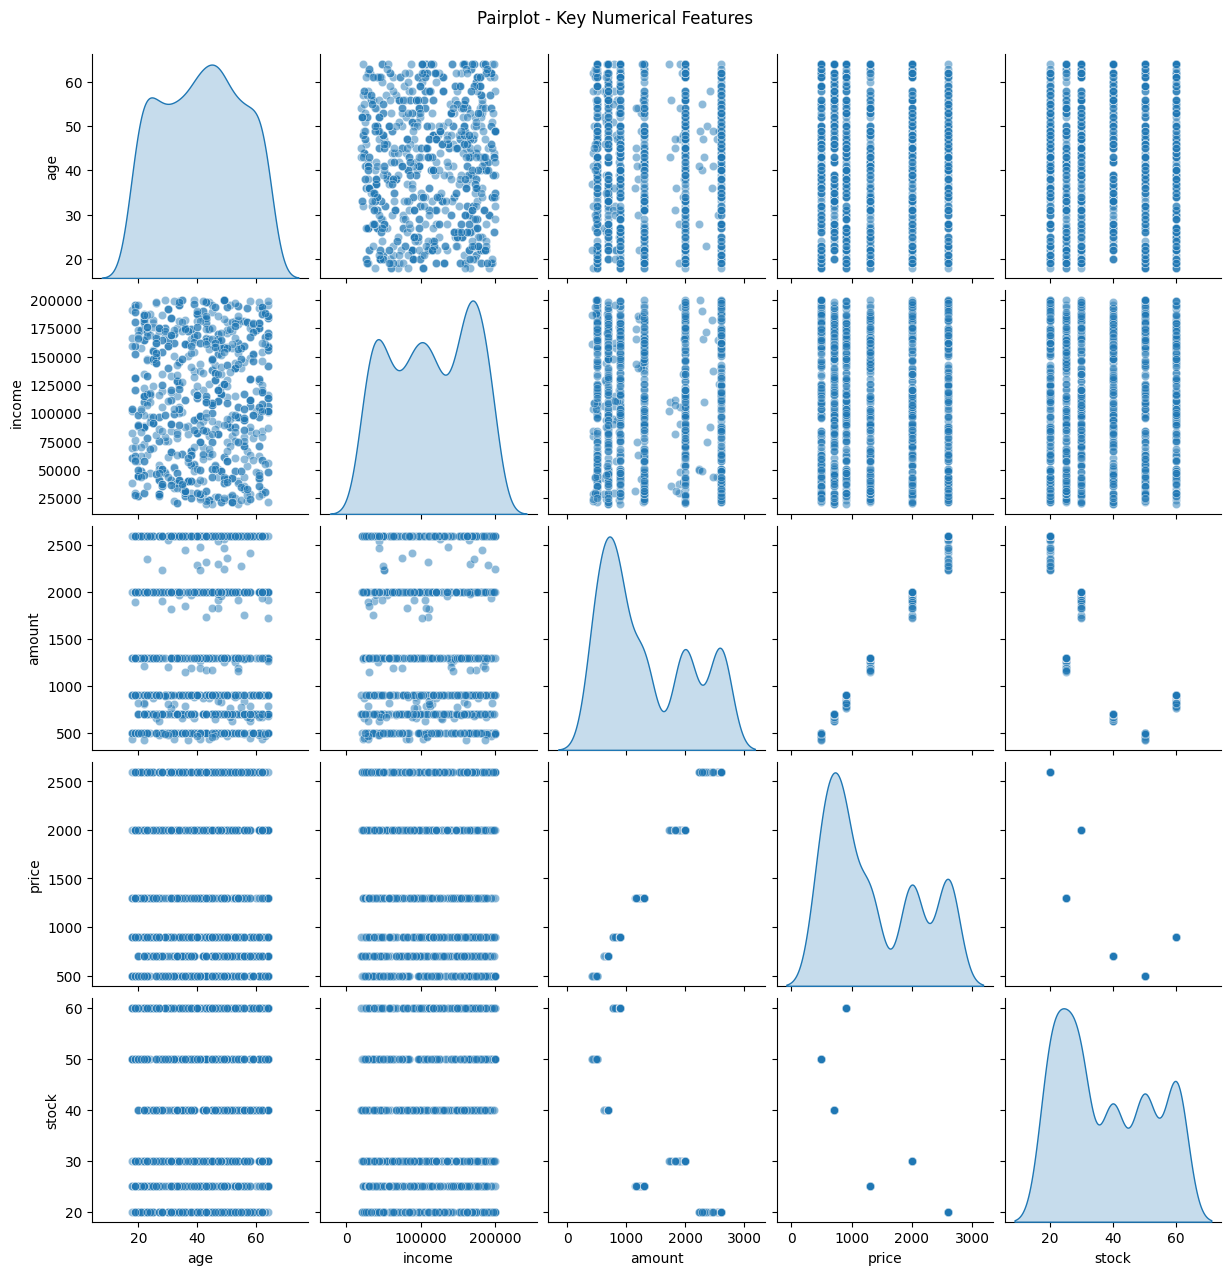

In [96]:
# multivariate analysis
# pairplot on key numerical features

sns.pairplot(df[["age","income","amount","price","stock"]].dropna(), diag_kind="kde", plot_kws={"alpha":0.5})
plt.suptitle("Pairplot - Key Numerical Features", y=1.02)
plt.show()

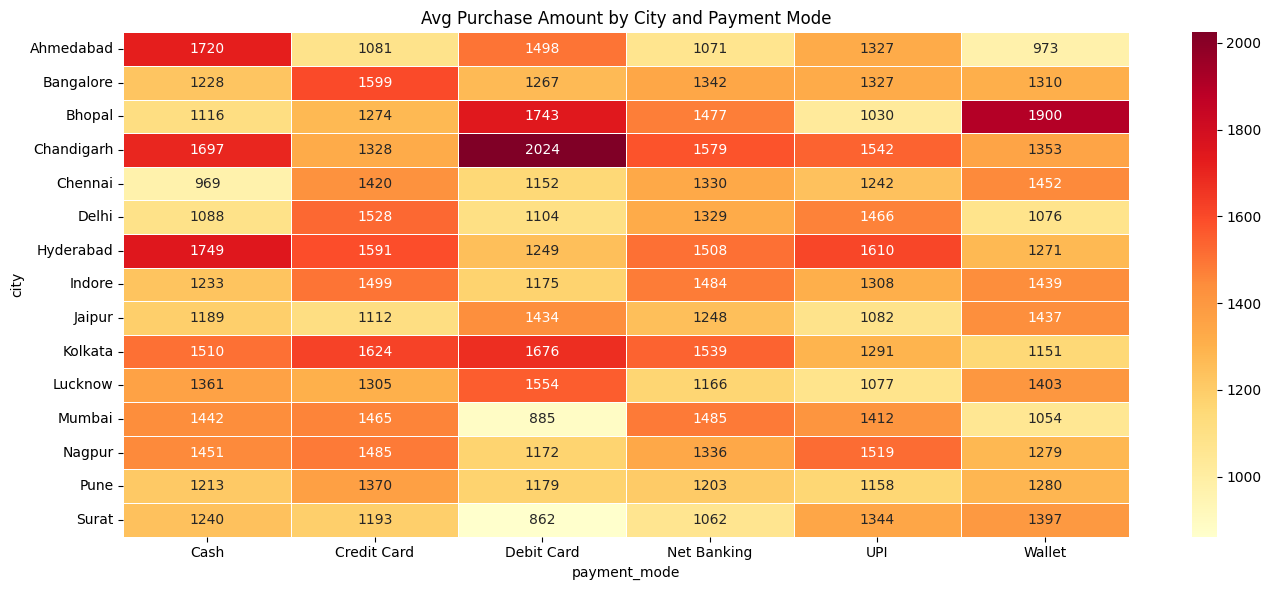

In [97]:
# grouped statistics: avg amount by city and payment_mode

grouped = df.groupby(["city","payment_mode"])["amount"].mean().reset_index()
pivot = grouped.pivot(index="city", columns="payment_mode", values="amount")
plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.4)
plt.title("Avg Purchase Amount by City and Payment Mode")
plt.tight_layout()
plt.show()

## 🩹 Step 4: Handling Missing Data

In [98]:
# simple imputer
df_simple = df.copy()

mean_imputer = SimpleImputer(strategy="mean")
median_imputer = SimpleImputer(strategy="median")
frequent_imputer = SimpleImputer(strategy="most_frequent")

df_simple[["gender","city","payment_mode","category"]] = frequent_imputer.fit_transform(df_simple[["gender","city","payment_mode","category"]])

df_simple[["age"]] = mean_imputer.fit_transform(df_simple[["age"]])

df_simple[["income","amount","price","stock"]] = median_imputer.fit_transform(df_simple[["income","amount","price","stock"]])

print("after applying simple imputer")
print(df_simple.isnull().sum())
display(df_simple.head())

after applying simple imputer
transaction_id    0
customer_id       0
product_id        0
amount            0
payment_mode      0
date              0
quantity          0
product_name      0
category          0
price             0
stock             0
name              0
age               0
gender            0
city              0
income            0
purchased         0
dtype: int64


,transaction_id,customer_id,product_id,amount,payment_mode,date,quantity,product_name,category,price,stock,name,age,gender,city,income,purchased
0,T0001,910,P003,1299.0,Credit Card,2025-03-31,3,Smart Watch,Wearable,1299.0,25.0,Dinesh,27.0,Male,Kolkata,42207.0,1
1,T0002,977,P006,2599.0,Cash,2025-09-21,2,Power Bank,Mobile Accessories,2599.0,20.0,Satish,45.0,Male,Mumbai,189316.0,1
2,T0003,189,P004,899.0,Credit Card,2025-03-13,2,Keyboard,Computer,899.0,60.0,Rohan,62.0,Male,Hyderabad,103588.0,1
3,T0004,432,P002,631.0,Cash,2025-05-17,2,Bluetooth Speaker,Audio,699.0,40.0,Deepa,52.0,Male,Chandigarh,43284.0,1
4,T0005,410,P005,1999.0,UPI,2025-05-14,3,Headphones,Audio,1999.0,30.0,Usha,50.0,Male,Indore,41621.0,1


In [99]:
# missing indicator and random sample imputation

df_random = df.copy()

def random_sample_imputer(df, col, random_state=18):
    null_count = df[col].isnull().sum()
    if null_count > 0:
        random_value = df[col].dropna().sample(
            n=null_count, replace=True, random_state=random_state).values
        df_ = df.copy()
        df_.loc[df_[col].isnull(), col] = random_value
        return df_
    return df

miss_ind = MissingIndicator(features='missing-only')
miss_ind_array = miss_ind.fit_transform(df)
miss_ind_col = [df.columns[col] + '_missing' for col in miss_ind.features_]
df_miss_ind = pd.DataFrame(miss_ind_array.astype(int), columns=miss_ind_col)

print("\nNew indicator columns created:", miss_ind_col)
display(df_miss_ind.head())

df_random = pd.concat([df_random.reset_index(drop=True), df_miss_ind], axis=1)
print("\nShape after adding indicator columns:", df_random.shape)

for col in df_random.select_dtypes(include=np.number).columns:
    df_random = random_sample_imputer(df_random, col)

print("after applying random imputation")
display(df_random.head())
print(df_random.isnull().sum())


New indicator columns created: ['age_missing', 'income_missing']


,age_missing,income_missing
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0



Shape after adding indicator columns: (1000, 19)
after applying random imputation


,transaction_id,customer_id,product_id,amount,payment_mode,date,quantity,product_name,category,price,stock,name,age,gender,city,income,purchased,age_missing,income_missing
0,T0001,910,P003,1299,Credit Card,2025-03-31,3,Smart Watch,Wearable,1299,25,Dinesh,27.0,Male,Kolkata,42207.0,1,0,0
1,T0002,977,P006,2599,Cash,2025-09-21,2,Power Bank,Mobile Accessories,2599,20,Satish,45.0,Male,Mumbai,189316.0,1,0,0
2,T0003,189,P004,899,Credit Card,2025-03-13,2,Keyboard,Computer,899,60,Rohan,62.0,Male,Hyderabad,103588.0,1,0,0
3,T0004,432,P002,631,Cash,2025-05-17,2,Bluetooth Speaker,Audio,699,40,Deepa,52.0,Male,Chandigarh,43284.0,1,0,0
4,T0005,410,P005,1999,UPI,2025-05-14,3,Headphones,Audio,1999,30,Usha,50.0,Male,Indore,41621.0,1,0,0


transaction_id    0
customer_id       0
product_id        0
amount            0
payment_mode      0
date              0
quantity          0
product_name      0
category          0
price             0
stock             0
name              0
age               0
gender            0
city              0
income            0
purchased         0
age_missing       0
income_missing    0
dtype: int64


In [100]:
# knn imputer

df_knn = df.copy()

id_cols = ["customer_id","transaction_id","product_id","name","date"]
df_knn_dropped = df_knn[id_cols].copy()
df_knn.drop(id_cols, axis=1, inplace=True)

cat_cols = ["gender","city","payment_mode","category","product_name"]
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
df_knn[cat_cols] = oe.fit_transform(df_knn[cat_cols])

knn = KNNImputer(n_neighbors=10, weights='distance')
df_knn = pd.DataFrame(knn.fit_transform(df_knn), columns=df_knn.columns)

df_knn[cat_cols] = df_knn[cat_cols].round().astype(int)
df_knn[cat_cols] = oe.inverse_transform(df_knn[cat_cols])

df_knn = pd.concat([df_knn_dropped.reset_index(drop=True), df_knn.reset_index(drop=True)], axis=1)

print("After applying KNNImputer:")
display(df_knn.head(10))
print(df_knn.isnull().sum())

After applying KNNImputer:


,customer_id,transaction_id,product_id,name,date,amount,payment_mode,quantity,product_name,category,price,stock,age,gender,city,income,purchased
0,910,T0001,P003,Dinesh,2025-03-31,1299.0,Credit Card,3.0,Smart Watch,Wearable,1299.0,25.0,27.000000,Male,Kolkata,42207.0,1.0
1,977,T0002,P006,Satish,2025-09-21,2599.0,Cash,2.0,Power Bank,Mobile Accessories,2599.0,20.0,45.000000,Male,Mumbai,189316.0,1.0
2,189,T0003,P004,Rohan,2025-03-13,899.0,Credit Card,2.0,Keyboard,Computer,899.0,60.0,62.000000,Male,Hyderabad,103588.0,1.0
3,432,T0004,P002,Deepa,2025-05-17,631.0,Cash,2.0,Bluetooth Speaker,Audio,699.0,40.0,52.000000,Male,Chandigarh,43284.0,1.0
4,410,T0005,P005,Usha,2025-05-14,1999.0,UPI,3.0,Headphones,Audio,1999.0,30.0,50.000000,Male,Indore,41621.0,1.0
5,469,T0006,P006,Rekha,2025-03-02,2599.0,Wallet,2.0,Power Bank,Mobile Accessories,2599.0,20.0,36.134614,Female,Chennai,188553.0,1.0
6,415,T0007,P002,Jyoti,2025-06-09,699.0,Net Banking,3.0,Bluetooth Speaker,Audio,699.0,40.0,47.000000,Female,Chennai,50447.0,1.0
7,221,T0008,P006,Shreya,2025-07-08,2599.0,Debit Card,3.0,Power Bank,Mobile Accessories,2599.0,20.0,38.528575,Female,Jaipur,193672.0,1.0
8,327,T0009,P002,Ishaan,2025-03-20,699.0,Cash,2.0,Bluetooth Speaker,Audio,699.0,40.0,51.000000,Male,Kolkata,87695.0,1.0
9,866,T0010,P005,Satish,2025-10-09,1999.0,Wallet,2.0,Headphones,Audio,1999.0,30.0,45.000000,Female,Pune,106795.0,1.0


customer_id       0
transaction_id    0
product_id        0
name              0
date              0
amount            0
payment_mode      0
quantity          0
product_name      0
category          0
price             0
stock             0
age               0
gender            0
city              0
income            0
purchased         0
dtype: int64


In [101]:
# iterative imputer (MICE)

df_mice = df.copy()

id_cols = ["customer_id","transaction_id","product_id","name","date"]
df_mice_dropped = df_mice[id_cols].copy()
df_mice.drop(id_cols, axis=1, inplace=True)

cat_cols = ["gender","city","payment_mode","category","product_name"]
oe2 = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
df_mice[cat_cols] = oe2.fit_transform(df_mice[cat_cols])

mice = IterativeImputer(max_iter=175, random_state=18)
df_mice = pd.DataFrame(mice.fit_transform(df_mice), columns=df_mice.columns)

df_mice[cat_cols] = df_mice[cat_cols].round().astype(int)
df_mice[cat_cols] = oe2.inverse_transform(df_mice[cat_cols])

df_mice = pd.concat([df_mice_dropped.reset_index(drop=True), df_mice.reset_index(drop=True)], axis=1)

print("After applying MICE Algorithm:")
display(df_mice.head(10))
print(df_mice.isnull().sum())

After applying MICE Algorithm:


,customer_id,transaction_id,product_id,name,date,amount,payment_mode,quantity,product_name,category,price,stock,age,gender,city,income,purchased
0,910,T0001,P003,Dinesh,2025-03-31,1299.0,Credit Card,3.0,Smart Watch,Wearable,1299.0,25.0,27.000000,Male,Kolkata,42207.0,1.0
1,977,T0002,P006,Satish,2025-09-21,2599.0,Cash,2.0,Power Bank,Mobile Accessories,2599.0,20.0,45.000000,Male,Mumbai,189316.0,1.0
2,189,T0003,P004,Rohan,2025-03-13,899.0,Credit Card,2.0,Keyboard,Computer,899.0,60.0,62.000000,Male,Hyderabad,103588.0,1.0
3,432,T0004,P002,Deepa,2025-05-17,631.0,Cash,2.0,Bluetooth Speaker,Audio,699.0,40.0,52.000000,Male,Chandigarh,43284.0,1.0
4,410,T0005,P005,Usha,2025-05-14,1999.0,UPI,3.0,Headphones,Audio,1999.0,30.0,50.000000,Male,Indore,41621.0,1.0
5,469,T0006,P006,Rekha,2025-03-02,2599.0,Wallet,2.0,Power Bank,Mobile Accessories,2599.0,20.0,41.779202,Female,Chennai,188553.0,1.0
6,415,T0007,P002,Jyoti,2025-06-09,699.0,Net Banking,3.0,Bluetooth Speaker,Audio,699.0,40.0,47.000000,Female,Chennai,50447.0,1.0
7,221,T0008,P006,Shreya,2025-07-08,2599.0,Debit Card,3.0,Power Bank,Mobile Accessories,2599.0,20.0,41.823296,Female,Jaipur,193672.0,1.0
8,327,T0009,P002,Ishaan,2025-03-20,699.0,Cash,2.0,Bluetooth Speaker,Audio,699.0,40.0,51.000000,Male,Kolkata,87695.0,1.0
9,866,T0010,P005,Satish,2025-10-09,1999.0,Wallet,2.0,Headphones,Audio,1999.0,30.0,45.000000,Female,Pune,106795.0,1.0


customer_id       0
transaction_id    0
product_id        0
name              0
date              0
amount            0
payment_mode      0
quantity          0
product_name      0
category          0
price             0
stock             0
age               0
gender            0
city              0
income            0
purchased         0
dtype: int64


In [102]:
# complete case analysis
df_cca = df.copy()

print("Shape BEFORE dropping missing rows:", df_cca.shape)
print("Total missing values:\n", df_cca.isnull().sum())

df_cca = df_cca.dropna()

print("\nShape AFTER dropping missing rows:", df_cca.shape)
print("Total rows dropped:", df.shape[0] - df_cca.shape[0])
print("Total missing values after CCA:\n", df_cca.isnull().sum())

Shape BEFORE dropping missing rows: (1000, 17)
Total missing values:
 transaction_id     0
customer_id        0
product_id         0
amount             0
payment_mode       0
date               0
quantity           0
product_name       0
category           0
price              0
stock              0
name               0
age               51
gender             0
city               0
income            52
purchased          0
dtype: int64

Shape AFTER dropping missing rows: (897, 17)
Total rows dropped: 103
Total missing values after CCA:
 transaction_id    0
customer_id       0
product_id        0
amount            0
payment_mode      0
date              0
quantity          0
product_name      0
category          0
price             0
stock             0
name              0
age               0
gender            0
city              0
income            0
purchased         0
dtype: int64


## 🔎 Step 5: Outlier Detection & Handling

In [103]:
display(df_mice)

,customer_id,transaction_id,product_id,name,date,amount,payment_mode,quantity,product_name,category,price,stock,age,gender,city,income,purchased
0,910,T0001,P003,Dinesh,2025-03-31,1299.0,Credit Card,3.0,Smart Watch,Wearable,1299.0,25.0,27.0,Male,Kolkata,42207.0,1.0
1,977,T0002,P006,Satish,2025-09-21,2599.0,Cash,2.0,Power Bank,Mobile Accessories,2599.0,20.0,45.0,Male,Mumbai,189316.0,1.0
2,189,T0003,P004,Rohan,2025-03-13,899.0,Credit Card,2.0,Keyboard,Computer,899.0,60.0,62.0,Male,Hyderabad,103588.0,1.0
3,432,T0004,P002,Deepa,2025-05-17,631.0,Cash,2.0,Bluetooth Speaker,Audio,699.0,40.0,52.0,Male,Chandigarh,43284.0,1.0
4,410,T0005,P005,Usha,2025-05-14,1999.0,UPI,3.0,Headphones,Audio,1999.0,30.0,50.0,Male,Indore,41621.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,365,T0996,P003,Sandeep,2025-01-22,1299.0,Credit Card,3.0,Smart Watch,Wearable,1299.0,25.0,19.0,Male,Ahmedabad,188876.0,1.0
996,598,T0997,P001,Usha,2025-06-02,486.0,Debit Card,1.0,Earphones,Electronics,499.0,50.0,29.0,Male,Nagpur,199635.0,1.0
997,1023,T0998,P004,Rekha,2025-02-16,899.0,Wallet,2.0,Keyboard,Computer,899.0,60.0,64.0,Male,Jaipur,198570.0,1.0
998,1066,T0999,P006,Girish,2025-02-27,2599.0,Credit Card,3.0,Power Bank,Mobile Accessories,2599.0,20.0,19.0,Female,Delhi,130659.0,1.0


In [104]:
# Z-Score method
# will use df_mice moving forward

columns = ["age", "income", "amount", "price", "stock"]

def z_score(df, cols):
    threshold = 3
    df_z = df.copy()
    for col in cols:
        mean = df_z[col].mean()
        std = df_z[col].std()
        z = (df_z[col] - mean) / std
        df_z[col + "_z_score"] = z
        df_z = df_z[df_z[col + "_z_score"].abs() <= threshold].copy()
        df_z = df_z.drop(columns=[col + "_z_score"])
    return df_z

df_zscore = z_score(df=df_mice, cols=columns)

print("After applying Z-Score")
print(f"Records Removed: {len(df_mice) - len(df_zscore)}")
display(df_zscore)

After applying Z-Score
Records Removed: 0


,customer_id,transaction_id,product_id,name,date,amount,payment_mode,quantity,product_name,category,price,stock,age,gender,city,income,purchased
0,910,T0001,P003,Dinesh,2025-03-31,1299.0,Credit Card,3.0,Smart Watch,Wearable,1299.0,25.0,27.0,Male,Kolkata,42207.0,1.0
1,977,T0002,P006,Satish,2025-09-21,2599.0,Cash,2.0,Power Bank,Mobile Accessories,2599.0,20.0,45.0,Male,Mumbai,189316.0,1.0
2,189,T0003,P004,Rohan,2025-03-13,899.0,Credit Card,2.0,Keyboard,Computer,899.0,60.0,62.0,Male,Hyderabad,103588.0,1.0
3,432,T0004,P002,Deepa,2025-05-17,631.0,Cash,2.0,Bluetooth Speaker,Audio,699.0,40.0,52.0,Male,Chandigarh,43284.0,1.0
4,410,T0005,P005,Usha,2025-05-14,1999.0,UPI,3.0,Headphones,Audio,1999.0,30.0,50.0,Male,Indore,41621.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,365,T0996,P003,Sandeep,2025-01-22,1299.0,Credit Card,3.0,Smart Watch,Wearable,1299.0,25.0,19.0,Male,Ahmedabad,188876.0,1.0
996,598,T0997,P001,Usha,2025-06-02,486.0,Debit Card,1.0,Earphones,Electronics,499.0,50.0,29.0,Male,Nagpur,199635.0,1.0
997,1023,T0998,P004,Rekha,2025-02-16,899.0,Wallet,2.0,Keyboard,Computer,899.0,60.0,64.0,Male,Jaipur,198570.0,1.0
998,1066,T0999,P006,Girish,2025-02-27,2599.0,Credit Card,3.0,Power Bank,Mobile Accessories,2599.0,20.0,19.0,Female,Delhi,130659.0,1.0


In [105]:
# IQR method
def iqr(df, cols):
    df_iqr = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_fence = Q1 - 1.5 * IQR
        upper_fence = Q3 + 1.5 * IQR
        outlier_mask = (df[col] < lower_fence) | (df[col] > upper_fence)
        df_iqr = df_iqr[~outlier_mask]
    return df_iqr

df_IQR = iqr(df=df_mice, cols=columns)

print("After applying IQR")
print(f"Records Removed: {len(df_mice) - len(df_IQR)}")
display(df_IQR)

After applying IQR
Records Removed: 0


,customer_id,transaction_id,product_id,name,date,amount,payment_mode,quantity,product_name,category,price,stock,age,gender,city,income,purchased
0,910,T0001,P003,Dinesh,2025-03-31,1299.0,Credit Card,3.0,Smart Watch,Wearable,1299.0,25.0,27.0,Male,Kolkata,42207.0,1.0
1,977,T0002,P006,Satish,2025-09-21,2599.0,Cash,2.0,Power Bank,Mobile Accessories,2599.0,20.0,45.0,Male,Mumbai,189316.0,1.0
2,189,T0003,P004,Rohan,2025-03-13,899.0,Credit Card,2.0,Keyboard,Computer,899.0,60.0,62.0,Male,Hyderabad,103588.0,1.0
3,432,T0004,P002,Deepa,2025-05-17,631.0,Cash,2.0,Bluetooth Speaker,Audio,699.0,40.0,52.0,Male,Chandigarh,43284.0,1.0
4,410,T0005,P005,Usha,2025-05-14,1999.0,UPI,3.0,Headphones,Audio,1999.0,30.0,50.0,Male,Indore,41621.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,365,T0996,P003,Sandeep,2025-01-22,1299.0,Credit Card,3.0,Smart Watch,Wearable,1299.0,25.0,19.0,Male,Ahmedabad,188876.0,1.0
996,598,T0997,P001,Usha,2025-06-02,486.0,Debit Card,1.0,Earphones,Electronics,499.0,50.0,29.0,Male,Nagpur,199635.0,1.0
997,1023,T0998,P004,Rekha,2025-02-16,899.0,Wallet,2.0,Keyboard,Computer,899.0,60.0,64.0,Male,Jaipur,198570.0,1.0
998,1066,T0999,P006,Girish,2025-02-27,2599.0,Credit Card,3.0,Power Bank,Mobile Accessories,2599.0,20.0,19.0,Female,Delhi,130659.0,1.0


In [106]:
# Percentile method

def percentile(df, cols, lower, upper):
    df_perc = df.copy()
    for col in cols:
        lower_bound = df_perc[col].quantile(lower)
        upper_bound = df_perc[col].quantile(upper)
        outlier_mask = (df_perc[col] < lower_bound) | (df_perc[col] > upper_bound)
        df_perc = df_perc[~outlier_mask]
    return df_perc

df_percentile = percentile(df=df_mice, cols=columns, lower=0.05, upper=0.95)

print("After applying Percentile method")
print(f"Records Removed: {len(df_mice) - len(df_percentile)}")
display(df_percentile)

After applying Percentile method
Records Removed: 185


,customer_id,transaction_id,product_id,name,date,amount,payment_mode,quantity,product_name,category,price,stock,age,gender,city,income,purchased
0,910,T0001,P003,Dinesh,2025-03-31,1299.0,Credit Card,3.0,Smart Watch,Wearable,1299.0,25.0,27.0,Male,Kolkata,42207.0,1.0
1,977,T0002,P006,Satish,2025-09-21,2599.0,Cash,2.0,Power Bank,Mobile Accessories,2599.0,20.0,45.0,Male,Mumbai,189316.0,1.0
2,189,T0003,P004,Rohan,2025-03-13,899.0,Credit Card,2.0,Keyboard,Computer,899.0,60.0,62.0,Male,Hyderabad,103588.0,1.0
3,432,T0004,P002,Deepa,2025-05-17,631.0,Cash,2.0,Bluetooth Speaker,Audio,699.0,40.0,52.0,Male,Chandigarh,43284.0,1.0
4,410,T0005,P005,Usha,2025-05-14,1999.0,UPI,3.0,Headphones,Audio,1999.0,30.0,50.0,Male,Indore,41621.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
988,845,T0989,P006,Komal,2025-03-17,2282.0,Cash,1.0,Power Bank,Mobile Accessories,2599.0,20.0,55.0,Female,Kolkata,48803.0,1.0
989,255,T0990,P006,Riya,2025-08-11,2599.0,Debit Card,2.0,Power Bank,Mobile Accessories,2599.0,20.0,62.0,Male,Ahmedabad,118989.0,1.0
991,762,T0992,P002,Komal,2025-05-01,699.0,Net Banking,2.0,Bluetooth Speaker,Audio,699.0,40.0,33.0,Female,Jaipur,81709.0,1.0
993,576,T0994,P004,Neha,2025-08-05,899.0,Cash,3.0,Keyboard,Computer,899.0,60.0,40.0,Female,Jaipur,116468.0,1.0


In [107]:
# Winsorization
def winsorization(df, cols, lower, upper):
    df_win = df.copy()
    for col in cols:
        lower_win = df_win[col].quantile(lower)
        upper_win = df_win[col].quantile(upper)
        df_win[col] = df_win[col].clip(lower=lower_win, upper=upper_win)
    return df_win

df_winsorization = winsorization(df=df_mice, cols=columns, lower=0.05, upper=0.95)

print("After applying Winsorization method")
display(df_winsorization)

After applying Winsorization method


,customer_id,transaction_id,product_id,name,date,amount,payment_mode,quantity,product_name,category,price,stock,age,gender,city,income,purchased
0,910,T0001,P003,Dinesh,2025-03-31,1299.0,Credit Card,3.0,Smart Watch,Wearable,1299.0,25.0,27.0,Male,Kolkata,42207.00,1.0
1,977,T0002,P006,Satish,2025-09-21,2599.0,Cash,2.0,Power Bank,Mobile Accessories,2599.0,20.0,45.0,Male,Mumbai,189316.00,1.0
2,189,T0003,P004,Rohan,2025-03-13,899.0,Credit Card,2.0,Keyboard,Computer,899.0,60.0,62.0,Male,Hyderabad,103588.00,1.0
3,432,T0004,P002,Deepa,2025-05-17,631.0,Cash,2.0,Bluetooth Speaker,Audio,699.0,40.0,52.0,Male,Chandigarh,43284.00,1.0
4,410,T0005,P005,Usha,2025-05-14,1999.0,UPI,3.0,Headphones,Audio,1999.0,30.0,50.0,Male,Indore,41621.00,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,365,T0996,P003,Sandeep,2025-01-22,1299.0,Credit Card,3.0,Smart Watch,Wearable,1299.0,25.0,20.0,Male,Ahmedabad,188876.00,1.0
996,598,T0997,P001,Usha,2025-06-02,499.0,Debit Card,1.0,Earphones,Electronics,499.0,50.0,29.0,Male,Nagpur,193491.55,1.0
997,1023,T0998,P004,Rekha,2025-02-16,899.0,Wallet,2.0,Keyboard,Computer,899.0,60.0,62.0,Male,Jaipur,193491.55,1.0
998,1066,T0999,P006,Girish,2025-02-27,2599.0,Credit Card,3.0,Power Bank,Mobile Accessories,2599.0,20.0,20.0,Female,Delhi,130659.00,1.0


### we will proceed with our df_mice dataset or df_IQR dataset as there are no particular outlier disrupting the shape of data.

## 📅 Step 6: Handling Mixed & Date/Time Variables

In [108]:
# convert date column to datetime and derive features

df_IQR["date"] = pd.to_datetime(df_IQR["date"])

np.random.seed(18)

df_IQR["signup_date"] = pd.to_datetime("2020-01-01") + pd.to_timedelta(np.random.randint(0, 1000, size=len(df_IQR)), unit='D')

df_IQR["last_purchase_date"] = df_IQR["date"]

ref_date = pd.Timestamp("2025-10-15")

df_IQR["days_since_signup"] = (ref_date - df_IQR["signup_date"]).dt.days
df_IQR["days_since_last_purchase"] = (ref_date - df_IQR["last_purchase_date"]).dt.days

df_IQR["purchase_month"] = df_IQR["date"].dt.month
df_IQR["purchase_weekday"] = df_IQR["date"].dt.dayofweek

# handle mixed variable: extract numeric part from customer_id
df_IQR["customer_id_clean"] = df_IQR["customer_id"].astype(str).str.extract(r"(\d+)").astype(float)

print(df_IQR[["date","signup_date","last_purchase_date","days_since_signup","days_since_last_purchase","customer_id_clean"]].head())

        date signup_date last_purchase_date  days_since_signup  \
0 2025-03-31  2020-10-25         2025-03-31               1816   
1 2025-09-21  2020-10-02         2025-09-21               1839   
2 2025-03-13  2020-04-30         2025-03-13               1994   
3 2025-05-17  2022-04-17         2025-05-17               1277   
4 2025-05-14  2021-12-03         2025-05-14               1412   

   days_since_last_purchase  customer_id_clean  
0                       198              910.0  
1                        24              977.0  
2                       216              189.0  
3                       151              432.0  
4                       154              410.0  


## 🏷️ Step 7: Encoding Categorical Data

In [109]:
# Label Encoding

le = LabelEncoder()

df_IQR["gender_encoded"] = le.fit_transform(df_IQR["gender"].astype(str))
df_IQR["payment_mode_encoded"] = le.fit_transform(df_IQR["payment_mode"].astype(str))

display(df_IQR[["gender","gender_encoded","payment_mode","payment_mode_encoded"]].head())

,gender,gender_encoded,payment_mode,payment_mode_encoded
0,Male,1,Credit Card,1
1,Male,1,Cash,0
2,Male,1,Credit Card,1
3,Male,1,Cash,0
4,Male,1,UPI,4


In [110]:
# One Hot Encoding

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
cols_ohe = ["city", "category"]
encoded_arr = ohe.fit_transform(df_IQR[cols_ohe])
feature_names = ohe.get_feature_names_out(cols_ohe)

df_ohe = pd.DataFrame(encoded_arr, columns=feature_names, index=df_IQR.index)
df_IQR = pd.concat([df_IQR, df_ohe], axis=1)

print("New columns added:", list(feature_names))
display(df_IQR[cols_ohe + list(feature_names)].head())

New columns added: ['city_Bangalore', 'city_Bhopal', 'city_Chandigarh', 'city_Chennai', 'city_Delhi', 'city_Hyderabad', 'city_Indore', 'city_Jaipur', 'city_Kolkata', 'city_Lucknow', 'city_Mumbai', 'city_Nagpur', 'city_Pune', 'city_Surat', 'category_Computer', 'category_Electronics', 'category_Mobile Accessories', 'category_Wearable']


,city,category,city_Bangalore,city_Bhopal,city_Chandigarh,city_Chennai,city_Delhi,city_Hyderabad,city_Indore,city_Jaipur,city_Kolkata,city_Lucknow,city_Mumbai,city_Nagpur,city_Pune,city_Surat,category_Computer,category_Electronics,category_Mobile Accessories,category_Wearable
0,Kolkata,Wearable,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,Mumbai,Mobile Accessories,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,Hyderabad,Computer,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,Chandigarh,Audio,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Indore,Audio,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [111]:
# Ordinal Encoding for product_name

product_order = [sorted(df_IQR["product_name"].dropna().unique().tolist())]
ord_enc = OrdinalEncoder(categories=product_order, handle_unknown='use_encoded_value', unknown_value=-1)
df_IQR["product_name_encoded"] = ord_enc.fit_transform(df_IQR[["product_name"]])
print(df_IQR[["product_name","product_name_encoded"]].drop_duplicates().sort_values("product_name_encoded"))

         product_name  product_name_encoded
3   Bluetooth Speaker                   0.0
16          Earphones                   1.0
4          Headphones                   2.0
2            Keyboard                   3.0
1          Power Bank                   4.0
0         Smart Watch                   5.0


In [112]:
# Encoding Numerical Features — Binning income groups

kbd = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
df_IQR["income_bin"] = kbd.fit_transform(df_IQR[["income"]]).astype(int)

print("After applying quantile binning on income:")
display(df_IQR[["income","income_bin"]].head())
print(df_IQR["income_bin"].value_counts().sort_index())
print(f"Quantile bin edges: {kbd.bin_edges_[0].round(0)}")

After applying quantile binning on income:


,income,income_bin
0,42207.0,0
1,189316.0,3
2,103588.0,1
3,43284.0,0
4,41621.0,0


income_bin
0    249
1    251
2    248
3    252
Name: count, dtype: int64
Quantile bin edges: [ 20138.  66403. 113506. 161877. 199830.]


## 📐 Step 8: Feature Scaling

In [113]:
scale_cols = ["age", "income", "amount", "price", "stock",
              "days_since_signup", "days_since_last_purchase"]

# StandardScaler
standardization = StandardScaler()
scaled_names = [c + "_stds" for c in scale_cols]
df_IQR[scaled_names] = standardization.fit_transform(df_IQR[scale_cols])
print("StandardScaler:")
display(df_IQR[scaled_names].head())
df_IQR.drop(scaled_names, axis=1, inplace=True)

StandardScaler:


,age_stds,income_stds,amount_stds,price_stds,stock_stds,days_since_signup_stds,days_since_last_purchase_stds
0,-1.081758,-1.343939,-0.051324,-0.065868,-0.893005,0.751707,0.657227
1,0.288019,1.428997,1.671815,1.646705,-1.237396,0.830881,-1.415105
2,1.581696,-0.186936,-0.581521,-0.592814,1.517730,1.364441,0.871606
3,0.820710,-1.323638,-0.936753,-0.856287,0.140167,-1.103706,0.097459
4,0.668512,-1.354985,0.876520,0.856287,-0.548614,-0.638992,0.133189


In [114]:
# MinMaxScaler

minmax_scaler = MinMaxScaler()
minmax_names = [c + "_minmax" for c in scale_cols]
df_IQR[minmax_names] = minmax_scaler.fit_transform(df_IQR[scale_cols])
print("MinMax Scaling:")
display(df_IQR[minmax_names].head())
df_IQR.drop(minmax_names, axis=1, inplace=True)

MinMax Scaling:


,age_minmax,income_minmax,amount_minmax,price_minmax,stock_minmax,days_since_signup_minmax,days_since_last_purchase_minmax
0,0.195652,0.122816,0.401473,0.380952,0.125,0.703518,0.689895
1,0.586957,0.941489,1.000000,1.000000,0.000,0.726633,0.083624
2,0.956522,0.464406,0.217311,0.190476,1.000,0.882412,0.752613
3,0.739130,0.128809,0.093923,0.095238,0.500,0.161809,0.526132
4,0.695652,0.119555,0.723757,0.714286,0.250,0.297487,0.536585


In [115]:
# MaxAbsScaler

maxabs_scaler = MaxAbsScaler()
maxabs_names = [c + "_maxabs" for c in scale_cols]
df_IQR[maxabs_names] = maxabs_scaler.fit_transform(df_IQR[scale_cols])
print("MaxAbs Scaling:")
display(df_IQR[maxabs_names].head())
df_IQR.drop(maxabs_names, axis=1, inplace=True)

MaxAbs Scaling:


,age_maxabs,income_maxabs,amount_maxabs,price_maxabs,stock_maxabs,days_since_signup_maxabs,days_since_last_purchase_maxabs
0,0.421875,0.211215,0.499808,0.499808,0.416667,0.860256,0.689895
1,0.703125,0.947385,1.000000,1.000000,0.333333,0.871151,0.083624
2,0.968750,0.518381,0.345902,0.345902,1.000000,0.944576,0.752613
3,0.812500,0.216604,0.242786,0.268950,0.666667,0.604927,0.526132
4,0.781250,0.208282,0.769142,0.769142,0.500000,0.668877,0.536585


In [116]:
# RobustScaler

robust_scaler = RobustScaler()
robust_names = [c + "_robust" for c in scale_cols]
df_IQR[robust_names] = robust_scaler.fit_transform(df_IQR[scale_cols])
print("Robust Scaling:")
display(df_IQR[robust_names].head())
df_IQR.drop(robust_names, axis=1, inplace=True)

Robust Scaling:


,age_robust,income_robust,amount_robust,price_robust,stock_robust,days_since_signup_robust,days_since_last_purchase_robust
0,-0.652967,-0.746793,0.307692,0.307692,-0.6,0.449635,0.383562
1,0.165215,0.794034,1.307692,1.307692,-0.8,0.494404,-0.808219
2,0.937942,-0.103885,0.000000,0.000000,0.8,0.796107,0.506849
3,0.483397,-0.735513,-0.206154,-0.153846,0.0,-0.599513,0.061644
4,0.392488,-0.752931,0.846154,0.846154,-0.4,-0.336740,0.082192


In [117]:
# Normalizer

normalizer = Normalizer()
norm_names = [c + "_norm" for c in scale_cols]
df_IQR[norm_names] = normalizer.fit_transform(df_IQR[scale_cols])
print("Normalizer:")
display(df_IQR[norm_names].head())
df_IQR.drop(norm_names, axis=1, inplace=True)

Normalizer:


,age_norm,income_norm,amount_norm,price_norm,stock_norm,days_since_signup_norm,days_since_last_purchase_norm
0,0.000639,0.998121,0.030719,0.030719,0.000591,0.042945,0.004682
1,0.000238,0.999764,0.013725,0.013725,0.000106,0.009712,0.000127
2,0.000598,0.999737,0.008676,0.008676,0.000579,0.019244,0.002085
3,0.001201,0.999322,0.014568,0.016138,0.000924,0.029483,0.003486
4,0.001198,0.997122,0.047890,0.047890,0.000719,0.033828,0.003689


In [118]:
# ColumnTransformer — apply different scalers simultaneously

ct = ColumnTransformer(transformers=[
    ("std",  StandardScaler(),  ["age", "income"]),
    ("mm",   MinMaxScaler(),    ["amount", "price"]),
    ("rb",   RobustScaler(),    ["stock", "days_since_signup", "days_since_last_purchase"])
], remainder="passthrough")

ct_result = ct.fit_transform(df_IQR[scale_cols])
print("ColumnTransformer output shape:", ct_result.shape)
print("StandardScaler → age, income | MinMax → amount, price | Robust → stock, days cols")

ColumnTransformer output shape: (1000, 7)
StandardScaler → age, income | MinMax → amount, price | Robust → stock, days cols


## 🔧 Step 9: Feature Construction & Transformation

In [119]:
# Feature Construction — interaction features

ref_date = pd.Timestamp("2025-10-15")

months_since_signup = (ref_date - df_IQR["signup_date"]).dt.days / 30
months_since_signup = months_since_signup.replace(0, 1)

# transaction count per customer
txn_count = df_IQR.groupby("customer_id_clean")["transaction_id"].transform("count")
df_IQR["total_purchases"] = txn_count

# purchase_per_day = total spend / days since signup
df_IQR["purchase_per_day"] = df_IQR["amount"] / (df_IQR["days_since_signup"] + 1)

# avg spend per purchase
df_IQR["avg_spend_per_purchase"] = df_IQR["amount"] / df_IQR["total_purchases"]

# recency score
df_IQR["recency_score"] = 1 / (df_IQR["days_since_last_purchase"] + 1)

print("Feature Construction:")
display(df_IQR[["purchase_per_day","avg_spend_per_purchase","recency_score","total_purchases"]].head())

Feature Construction:


,purchase_per_day,avg_spend_per_purchase,recency_score,total_purchases
0,0.714915,1299.000000,0.005025,1
1,1.412500,2599.000000,0.040000,1
2,0.450627,299.666667,0.004608,3
3,0.493740,210.333333,0.006579,3
4,1.414720,666.333333,0.006452,3


In [120]:
# Log Transform

log_transformer = FunctionTransformer(func=np.log1p, inverse_func=np.expm1)
df_IQR["income_log"] = log_transformer.fit_transform(df_IQR[["income"]])
print("Log Transform:")
display(df_IQR[["income","income_log"]].head())
df_IQR.drop("income_log", axis=1, inplace=True)

Log Transform:


,income,income_log
0,42207.0,10.650365
1,189316.0,12.151178
2,103588.0,11.548186
3,43284.0,10.675561
4,41621.0,10.636384


In [121]:
# Square Root Transform

sqrt_transformer = FunctionTransformer(func=np.sqrt, inverse_func=np.square)
df_IQR["amount_sqrt"] = sqrt_transformer.fit_transform(df_IQR[["amount"]])
print("Square Root Transform:")
display(df_IQR[["amount","amount_sqrt"]].head())
df_IQR.drop("amount_sqrt", axis=1, inplace=True)

Square Root Transform:


,amount,amount_sqrt
0,1299.0,36.041643
1,2599.0,50.980388
2,899.0,29.983329
3,631.0,25.119713
4,1999.0,44.710178


In [122]:
# Reciprocal Transform
reciprocal_transformer = FunctionTransformer(func=lambda x: 1 / (x + 1))
df_IQR["days_since_signup_recip"] = reciprocal_transformer.fit_transform(df_IQR[["days_since_signup"]])
print("Reciprocal Transform:")
display(df_IQR[["days_since_signup","days_since_signup_recip"]].head())
df_IQR.drop("days_since_signup_recip", axis=1, inplace=True)

Reciprocal Transform:


,days_since_signup,days_since_signup_recip
0,1816,0.000550
1,1839,0.000543
2,1994,0.000501
3,1277,0.000782
4,1412,0.000708


In [123]:
# Box-Cox Transform

boxcox_transformer = PowerTransformer(method='box-cox')
df_IQR["amount_boxcox"] = boxcox_transformer.fit_transform(df_IQR[["amount"]])
print("Box-Cox Transform:")
display(df_IQR[["amount","amount_boxcox"]].head())
df_IQR.drop("amount_boxcox", axis=1, inplace=True)

Box-Cox Transform:


,amount,amount_boxcox
0,1299.0,0.254099
1,2599.0,1.402634
2,899.0,-0.379491
3,631.0,-1.005107
4,1999.0,0.974778


In [124]:
# Yeo-Johnson Transform

yeojohnson_transformer = PowerTransformer(method='yeo-johnson')
df_IQR["income_yj"] = yeojohnson_transformer.fit_transform(df_IQR[["income"]])
print("Yeo-Johnson Transform:")
display(df_IQR[["income","income_yj"]].head())
df_IQR.drop("income_yj", axis=1, inplace=True)

Yeo-Johnson Transform:


,income,income_yj
0,42207.0,-1.368384
1,189316.0,1.378964
2,103588.0,-0.140685
3,43284.0,-1.344962
4,41621.0,-1.381170


In [125]:
# Binning — quantile binning on income

kbd_q = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
df_IQR["income_quantile_bin"] = kbd_q.fit_transform(df_IQR[["income"]]).astype(int)
print("Quantile Binning on income:")
display(df_IQR[["income","income_quantile_bin"]].head())
print(f"Quantile bin edges: {kbd_q.bin_edges_[0].round(0)}")

Quantile Binning on income:


,income,income_quantile_bin
0,42207.0,0
1,189316.0,3
2,103588.0,1
3,43284.0,0
4,41621.0,0


Quantile bin edges: [ 20138.  66403. 113506. 161877. 199830.]


In [126]:
# Binarization — frequent_buyer flag

threshold = df_IQR["total_purchases"].median()
bin_transform = Binarizer(threshold=threshold)
df_IQR["frequent_buyer"] = bin_transform.fit_transform(df_IQR[["total_purchases"]]).astype(int)
print("Binarization — frequent_buyer (1 if purchases > median):")
display(df_IQR[["total_purchases","frequent_buyer"]].head(10))
print(df_IQR["frequent_buyer"].value_counts())

Binarization — frequent_buyer (1 if purchases > median):


,total_purchases,frequent_buyer
0,1,0
1,1,0
2,3,1
3,3,1
4,3,1
5,2,0
6,1,0
7,2,0
8,3,1
9,3,1


frequent_buyer
0    741
1    259
Name: count, dtype: int64


## 💾 Step 10: Final Output

In [127]:
# create target variable: purchased
purchased_customers = set(df_json["customer_id"].unique())
df_IQR["purchased"] = df_IQR["customer_id_clean"].apply(lambda x: 1 if x in purchased_customers else 0)

print("purchased value counts:")
print(df_IQR["purchased"].value_counts())

purchased value counts:
purchased
1    1000
Name: count, dtype: int64


In [128]:
# drop non-numeric / id columns before saving

drop_cols = ["name","transaction_id","product_id","product_name","date",
             "signup_date","last_purchase_date","customer_id","customer_id_clean",
             "city","category","gender","payment_mode"]

final_dataset = df_IQR.drop(columns=[c for c in drop_cols if c in df_IQR.columns])
final_dataset = final_dataset.select_dtypes(include=np.number)

final_dataset.to_csv("processed_customer_data.csv", index=False)

print("--- Final Dataset Summary ---")
print(f"Final Shape: {final_dataset.shape}")
print(f"Missing Values: {final_dataset.isnull().sum().sum()}")
print(f"Data Types:\n{final_dataset.dtypes.value_counts()}")
display(final_dataset.head())

--- Final Dataset Summary ---
Final Shape: (1000, 39)
Missing Values: 0
Data Types:
float64    28
int64       9
int32       2
Name: count, dtype: int64


,amount,quantity,price,stock,age,income,purchased,days_since_signup,days_since_last_purchase,purchase_month,...,category_Mobile Accessories,category_Wearable,product_name_encoded,income_bin,total_purchases,purchase_per_day,avg_spend_per_purchase,recency_score,income_quantile_bin,frequent_buyer
0,1299.0,3.0,1299.0,25.0,27.0,42207.0,1,1816,198,3,...,0.0,1.0,5.0,0,1,0.714915,1299.000000,0.005025,0,0
1,2599.0,2.0,2599.0,20.0,45.0,189316.0,1,1839,24,9,...,1.0,0.0,4.0,3,1,1.412500,2599.000000,0.040000,3,0
2,899.0,2.0,899.0,60.0,62.0,103588.0,1,1994,216,3,...,0.0,0.0,3.0,1,3,0.450627,299.666667,0.004608,1,1
3,631.0,2.0,699.0,40.0,52.0,43284.0,1,1277,151,5,...,0.0,0.0,0.0,0,3,0.493740,210.333333,0.006579,0,1
4,1999.0,3.0,1999.0,30.0,50.0,41621.0,1,1412,154,5,...,0.0,0.0,2.0,0,3,1.414720,666.333333,0.006452,0,1
